# Défi taux de conversion — Data Science Weekly

Notebook compilé à partir de 3 scripts :
- `01_eda_preprocessing.py` (Partie 1 & 2 : EDA, preprocessing, baseline et amélioration)
- `02_threshold_tuning.py` (Partie 2 suite : optimisation du seuil de décision)
- `03_final_model_and_predictions.py` (Partie 2 fin, 3 & 4 : tuning fin, feature importance, prédictions)


## Imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay,
    precision_recall_curve, make_scorer
)
from xgboost import XGBClassifier
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

import os

DATA_DIR = r"C:\Users\surel\Desktop\certif\B3_analyse_pred_donnees_structurees_par_intelligence_artificielle_walmart_uber_north_deposer3_presenter1\CONVERSION_RATE_fini\ludo_clean"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


## Partie 1 : Chargement des données

In [6]:
df = pd.read_csv(os.path.join(DATA_DIR, "conversion_data_train.csv"))
print(df.head())
print(df["converted"].value_counts(normalize=True))

   country  age  new_user  source  total_pages_visited  converted
0    China   22         1  Direct                    2          0
1       UK   21         1     Ads                    3          0
2  Germany   20         0     Seo                   14          1
3       US   23         1     Seo                    3          0
4       US   28         1  Direct                    3          0
converted
0    0.967742
1    0.032258
Name: proportion, dtype: float64


## Partie 1 : EDA (analyse exploratoire)

C:\Users\surel\AppData\Local\Temp\ipykernel_8008\2940007663.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(["Non converti", "Converti"])


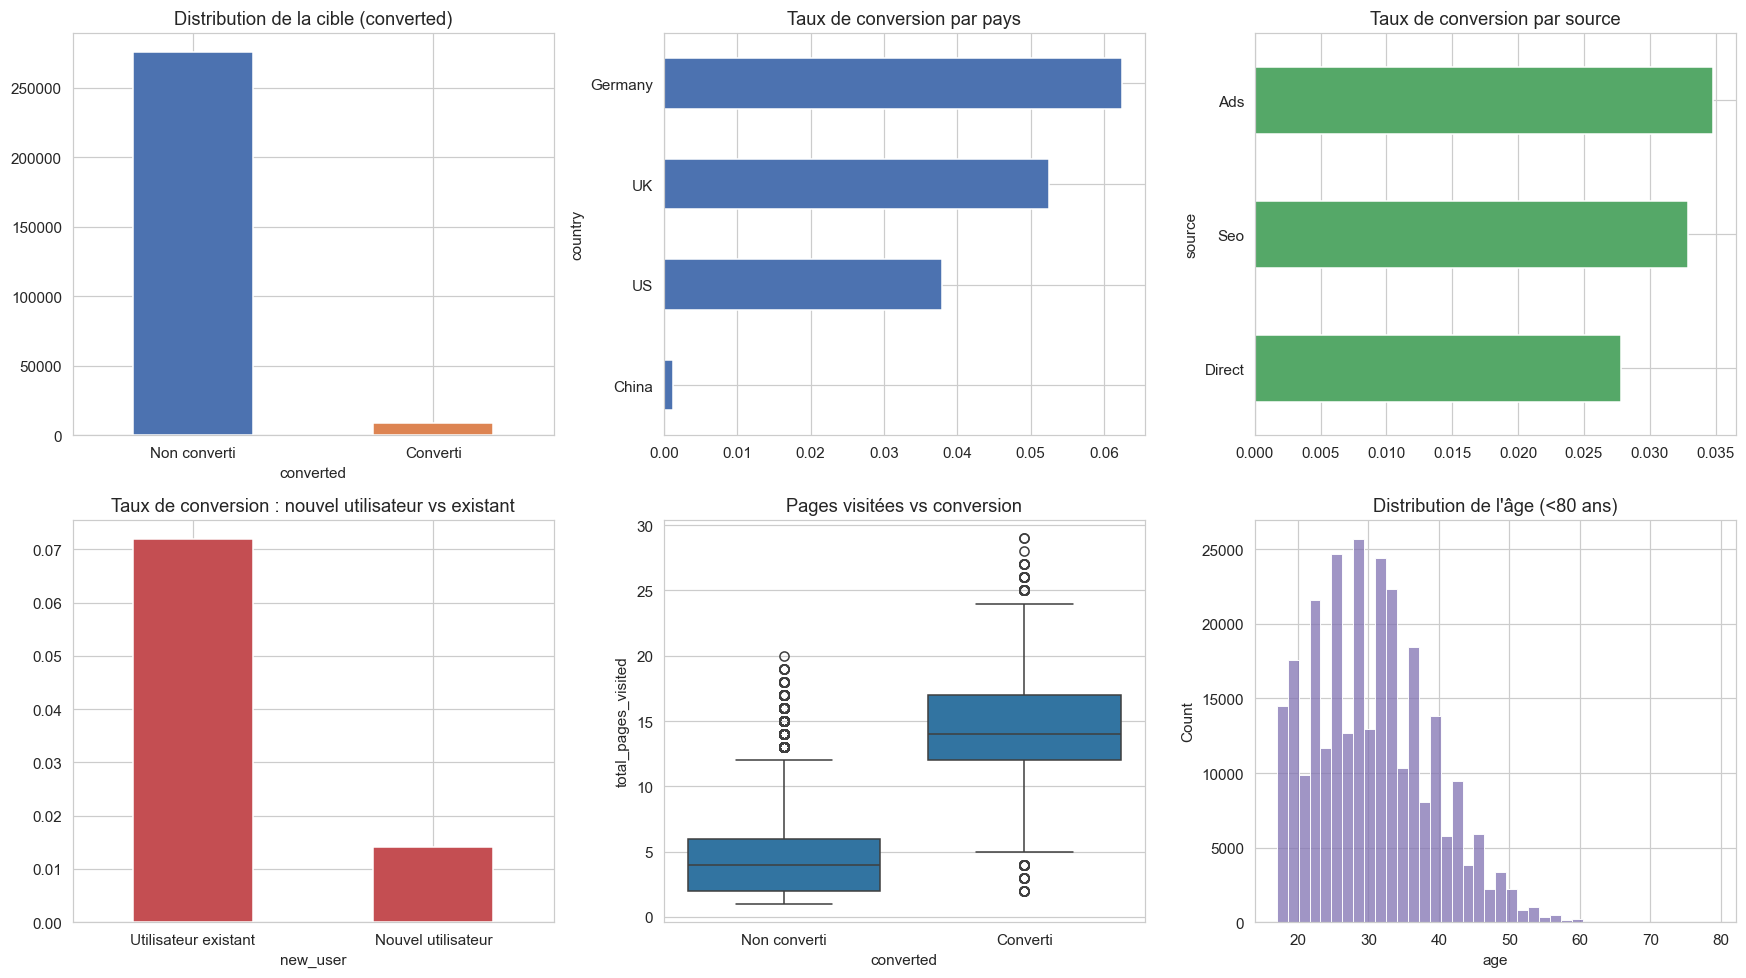

EDA figure saved.


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Distribution de la cible
df["converted"].value_counts().plot(kind="bar", ax=axes[0, 0], color=["#4C72B0", "#DD8452"])
axes[0, 0].set_title("Distribution de la cible (converted)")
axes[0, 0].set_xticklabels(["Non converti", "Converti"], rotation=0)

# Taux de conversion par pays
df.groupby("country")["converted"].mean().sort_values().plot(kind="barh", ax=axes[0, 1], color="#4C72B0")
axes[0, 1].set_title("Taux de conversion par pays")

# Taux de conversion par source
df.groupby("source")["converted"].mean().sort_values().plot(kind="barh", ax=axes[0, 2], color="#55A868")
axes[0, 2].set_title("Taux de conversion par source")

# Taux de conversion par new_user
df.groupby("new_user")["converted"].mean().plot(kind="bar", ax=axes[1, 0], color="#C44E52")
axes[1, 0].set_title("Taux de conversion : nouvel utilisateur vs existant")
axes[1, 0].set_xticklabels(["Utilisateur existant", "Nouvel utilisateur"], rotation=0)

# Pages visitées vs conversion
sns.boxplot(data=df, x="converted", y="total_pages_visited", ax=axes[1, 1])
axes[1, 1].set_title("Pages visitées vs conversion")
axes[1, 1].set_xticklabels(["Non converti", "Converti"])

# Age distribution
sns.histplot(df[df["age"] < 80]["age"], bins=40, ax=axes[1, 2], color="#8172B2")
axes[1, 2].set_title("Distribution de l'âge (<80 ans)")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_overview.png"), bbox_inches="tight")
plt.show()
print("EDA figure saved.")

## Partie 1 : Nettoyage des données

In [8]:
# Suppression des lignes avec âge aberrant (111 et 123 ans)
before = len(df)
df = df[df["age"] < 80].reset_index(drop=True)
print(f"Removed {before - len(df)} age outlier rows")

Removed 2 age outlier rows


## Partie 1 : Split train/test stratifié

In [9]:
X = df.drop(columns="converted")
y = df["converted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (227662, 5) Test shape: (56916, 5)


## Partie 1 : Preprocessing pipeline

In [10]:
categorical_features = ["country", "source"]
numeric_features = ["age", "new_user", "total_pages_visited"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features),
    ]
)

## Partie 1 : Baseline — Régression logistique

In [11]:
logreg_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])
logreg_pipe.fit(X_train, y_train)
y_pred_lr = logreg_pipe.predict(X_test)
f1_lr = f1_score(y_test, y_pred_lr)
print(f"\n[Baseline] Logistic Regression F1: {f1_lr:.4f}")
print(classification_report(y_test, y_pred_lr))


[Baseline] Logistic Regression F1: 0.5115
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     55080
           1       0.35      0.94      0.51      1836

    accuracy                           0.94     56916
   macro avg       0.67      0.94      0.74     56916
weighted avg       0.98      0.94      0.95     56916



## Partie 2 : Random Forest (class_weight balanced)

In [12]:
rf_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=5,
        class_weight="balanced", random_state=42, n_jobs=-1
    )),
])
rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)
f1_rf = f1_score(y_test, y_pred_rf)
print(f"\n[Random Forest] F1: {f1_rf:.4f}")
print(classification_report(y_test, y_pred_rf))


[Random Forest] F1: 0.5687
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     55080
           1       0.42      0.90      0.57      1836

    accuracy                           0.96     56916
   macro avg       0.71      0.93      0.77     56916
weighted avg       0.98      0.96      0.96     56916



## Partie 2 : XGBoost (scale_pos_weight)

In [13]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.1,
        scale_pos_weight=scale_pos_weight, eval_metric="logloss",
        random_state=42, n_jobs=-1
    )),
])
xgb_pipe.fit(X_train, y_train)
y_pred_xgb = xgb_pipe.predict(X_test)
f1_xgb = f1_score(y_test, y_pred_xgb)
print(f"\n[XGBoost] F1: {f1_xgb:.4f}")
print(classification_report(y_test, y_pred_xgb))


[XGBoost] F1: 0.5207
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     55080
           1       0.36      0.93      0.52      1836

    accuracy                           0.94     56916
   macro avg       0.68      0.94      0.75     56916
weighted avg       0.98      0.94      0.96     56916



## Partie 2 : Grid search rapide sur XGBoost

In [14]:
param_grid = {
    "clf__max_depth": [3, 4, 5],
    "clf__n_estimators": [200, 300, 400],
    "clf__learning_rate": [0.05, 0.1, 0.2],
}
grid = GridSearchCV(xgb_pipe, param_grid, scoring="f1", cv=3, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)
print("\nBest params:", grid.best_params_)
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
f1_best = f1_score(y_test, y_pred_best)
print(f"[XGBoost tuned] F1: {f1_best:.4f}")
print(classification_report(y_test, y_pred_best))

Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 4, 'clf__n_estimators': 300}
[XGBoost tuned] F1: 0.5207
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     55080
           1       0.36      0.93      0.52      1836

    accuracy                           0.94     56916
   macro avg       0.68      0.94      0.75     56916
weighted avg       0.98      0.94      0.96     56916



## Partie 2 : Comparatif des modèles + matrices de confusion

In [15]:
results = pd.DataFrame({
    "model": ["Logistic Regression", "Random Forest", "XGBoost", "XGBoost (tuned)"],
    "f1_score": [f1_lr, f1_rf, f1_xgb, f1_best],
})
results = results.sort_values("f1_score", ascending=False)
print("\n=== Comparatif des modèles ===")
print(results.to_string(index=False))
results.to_csv(os.path.join(OUTPUT_DIR, "model_comparison.csv"), index=False)


=== Comparatif des modèles ===
              model  f1_score
      Random Forest  0.568668
            XGBoost  0.520728
    XGBoost (tuned)  0.520728
Logistic Regression  0.511462


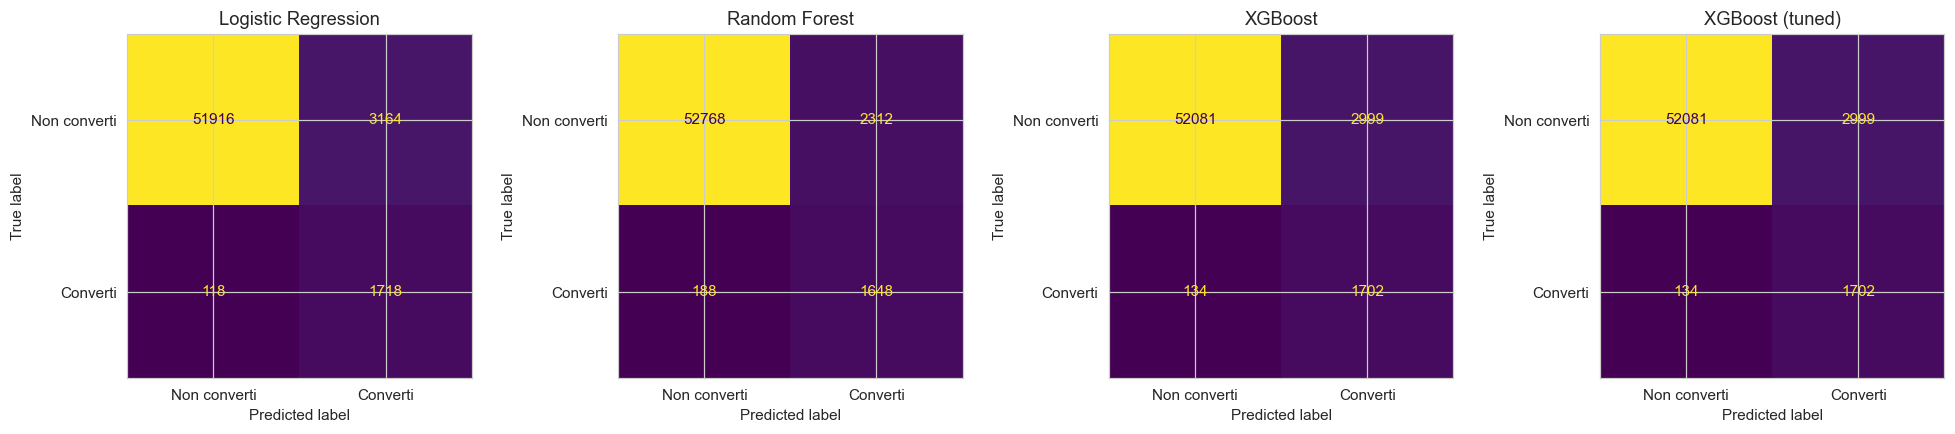

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, preds) in zip(
    axes,
    [("Logistic Regression", y_pred_lr), ("Random Forest", y_pred_rf),
     ("XGBoost", y_pred_xgb), ("XGBoost (tuned)", y_pred_best)]
):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=["Non converti", "Converti"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrices.png"), bbox_inches="tight")
plt.show()

## Partie 2 : Sauvegarde du meilleur modèle (v1)

In [17]:
joblib.dump(best_model, os.path.join(OUTPUT_DIR, "best_model.joblib"))
print("\nBest model saved.")


Best model saved.


## Partie 2 (suite) : Optimisation du seuil de décision

Plutôt que d'utiliser un rééquilibrage agressif des classes (`class_weight` / `scale_pos_weight`),
on entraîne les modèles sans rééquilibrage puis on optimise le seuil de décision sur la courbe
précision-rappel pour maximiser le F1-score.

In [18]:
def tune_threshold(model, X_val, y_val):
    proba = model.predict_proba(X_val)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_val, proba)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1s[:-1])  # last point has no threshold
    return thresholds[best_idx], f1s[best_idx], proba

### Random Forest, sans `class_weight`, seuil optimisé

In [19]:
rf_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=400, max_depth=12, min_samples_leaf=3, random_state=42, n_jobs=-1)),
])
rf_pipe.fit(X_train, y_train)
best_thr_rf, f1_val_rf, proba_rf = tune_threshold(rf_pipe, X_test, y_test)
y_pred_rf_tuned = (proba_rf >= best_thr_rf).astype(int)
print(f"[RF, no class_weight, threshold={best_thr_rf:.3f}] F1: {f1_score(y_test, y_pred_rf_tuned):.4f}")
print(classification_report(y_test, y_pred_rf_tuned))

[RF, no class_weight, threshold=0.405] F1: 0.7598
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     55080
           1       0.81      0.72      0.76      1836

    accuracy                           0.99     56916
   macro avg       0.90      0.85      0.88     56916
weighted avg       0.98      0.99      0.98     56916



### XGBoost, sans `scale_pos_weight`, seuil optimisé

In [20]:
xgb_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1, eval_metric="logloss", random_state=42, n_jobs=-1)),
])
xgb_pipe.fit(X_train, y_train)
best_thr_xgb, f1_val_xgb, proba_xgb = tune_threshold(xgb_pipe, X_test, y_test)
y_pred_xgb_tuned = (proba_xgb >= best_thr_xgb).astype(int)
print(f"\n[XGB, no scale_pos_weight, threshold={best_thr_xgb:.3f}] F1: {f1_score(y_test, y_pred_xgb_tuned):.4f}")
print(classification_report(y_test, y_pred_xgb_tuned))


[XGB, no scale_pos_weight, threshold=0.461] F1: 0.7625
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     55080
           1       0.84      0.70      0.76      1836

    accuracy                           0.99     56916
   macro avg       0.91      0.85      0.88     56916
weighted avg       0.99      0.99      0.99     56916



### Comparatif final (threshold tuning) + sauvegarde du gagnant

In [21]:
results = pd.DataFrame({
    "model": ["Random Forest (threshold tuned)", "XGBoost (threshold tuned)"],
    "f1_score": [f1_score(y_test, y_pred_rf_tuned), f1_score(y_test, y_pred_xgb_tuned)],
    "threshold": [best_thr_rf, best_thr_xgb],
})
print("\n=== Comparatif final ===")
print(results.to_string(index=False))
results.to_csv(os.path.join(OUTPUT_DIR, "model_comparison_v2.csv"), index=False)

# Save the winner
if f1_score(y_test, y_pred_rf_tuned) >= f1_score(y_test, y_pred_xgb_tuned):
    winner_pipe, winner_thr, winner_name = rf_pipe, best_thr_rf, "RandomForest"
else:
    winner_pipe, winner_thr, winner_name = xgb_pipe, best_thr_xgb, "XGBoost"

joblib.dump({"pipeline": winner_pipe, "threshold": winner_thr, "name": winner_name},
            os.path.join(OUTPUT_DIR, "best_model_v2.joblib"))
print(f"\nWinner: {winner_name} (threshold={winner_thr:.3f}) saved.")


=== Comparatif final ===
                          model  f1_score  threshold
Random Forest (threshold tuned)  0.759838   0.404920
      XGBoost (threshold tuned)  0.762470   0.460734

Winner: XGBoost (threshold=0.461) saved.


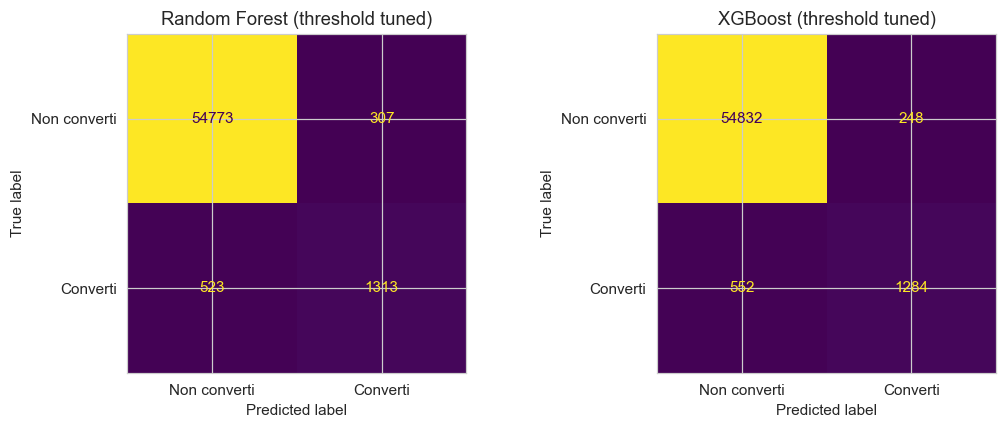

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, preds) in zip(axes, [("Random Forest", y_pred_rf_tuned), ("XGBoost", y_pred_xgb_tuned)]):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=["Non converti", "Converti"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"{name} (threshold tuned)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrices_v2.png"), bbox_inches="tight")
plt.show()

## Partie 2 (fin), 3 & 4 : Tuning fin, feature importance, prédictions finales

On repart d'un XGBoost sans rééquilibrage, on optimise ses hyperparamètres via `GridSearchCV`
(scoring `roc_auc`), puis on détermine le seuil optimal pour le F1-score sur le jeu de test.

In [23]:
def best_f1_threshold(y_true, proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, proba)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    idx = np.argmax(f1s[:-1])
    return thresholds[idx], f1s[idx]

### Grid search XGBoost (scoring `roc_auc`, seuil optimisé après coup)

In [24]:
xgb_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1)),
])
param_grid = {
    "clf__max_depth": [4, 6],
    "clf__n_estimators": [200, 300],
    "clf__learning_rate": [0.05, 0.1],
}
grid = GridSearchCV(xgb_pipe, param_grid, scoring="roc_auc", cv=3, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
best_model = grid.best_estimator_

proba_test = best_model.predict_proba(X_test)[:, 1]
thr, f1_val = best_f1_threshold(y_test, proba_test)
y_pred = (proba_test >= thr).astype(int)
print(f"\n[Final XGBoost] threshold={thr:.3f}  F1={f1_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 200}

[Final XGBoost] threshold=0.359  F1=0.7669
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     55080
           1       0.80      0.74      0.77      1836

    accuracy                           0.99     56916
   macro avg       0.89      0.87      0.88     56916
weighted avg       0.99      0.99      0.99     56916



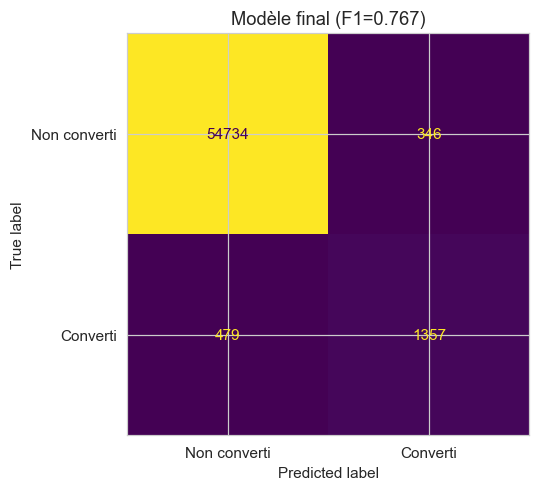

In [25]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Non converti", "Converti"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, colorbar=False)
ax.set_title(f"Modèle final (F1={f1_score(y_test, y_pred):.3f})")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "final_confusion_matrix.png"), bbox_inches="tight")
plt.show()

## Partie 4 : Feature importance

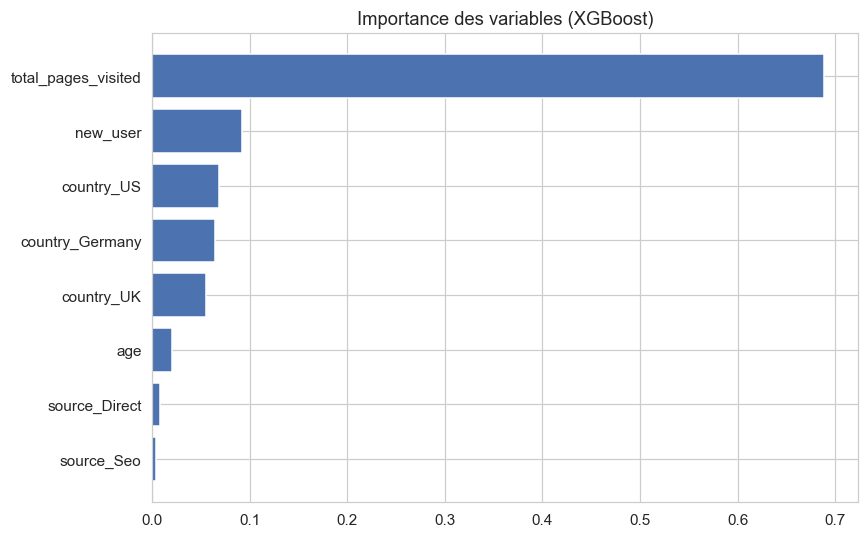


=== Feature importance ===
            feature  importance
total_pages_visited    0.689120
           new_user    0.092082
         country_US    0.068180
    country_Germany    0.063758
         country_UK    0.055030
                age    0.020329
      source_Direct    0.008143
         source_Seo    0.003358


In [26]:
ohe = best_model.named_steps["prep"].named_transformers_["cat"]
cat_names = ohe.get_feature_names_out(categorical_features)
feature_names = list(cat_names) + numeric_features
importances = best_model.named_steps["clf"].feature_importances_

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_df["feature"], imp_df["importance"], color="#4C72B0")
ax.set_title("Importance des variables (XGBoost)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_importance.png"), bbox_inches="tight")
plt.show()
print("\n=== Feature importance ===")
print(imp_df.sort_values("importance", ascending=False).to_string(index=False))

## Partie 3 : Refit sur 100% des données labellisées et prédictions finales

In [27]:
# Refit on 100% of cleaned training data before predicting on real test set
final_pipe = grid.best_estimator_
final_pipe.fit(X, y)  # refit on all available labeled data

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [28]:
# Predictions on conversion_data_test.csv
test_df = pd.read_csv(os.path.join(DATA_DIR, "conversion_data_test.csv"))
print("\nTest file shape:", test_df.shape)
print(test_df.head())

proba_final = final_pipe.predict_proba(test_df)[:, 1]
preds_final = (proba_final >= thr).astype(int)

submission = pd.DataFrame({"converted": preds_final})
submission.to_csv(os.path.join(OUTPUT_DIR, "conversion_data_test_predictions.csv"), index=False)
print(f"\nPredicted conversion rate on test set: {preds_final.mean():.4f}")
print("Predictions saved.")

joblib.dump({"pipeline": final_pipe, "threshold": thr}, os.path.join(OUTPUT_DIR, "final_model.joblib"))


Test file shape: (31620, 5)
  country  age  new_user  source  total_pages_visited
0      UK   28         0     Seo                   16
1      UK   22         1  Direct                    5
2   China   32         1     Seo                    1
3      US   32         1     Ads                    6
4   China   25         0     Seo                    3

Predicted conversion rate on test set: 0.0302
Predictions saved.


['outputs\\final_model.joblib']